In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('~/latex-cm.mplstyle')
colors = sns.color_palette('colorblind')

sys.path.append('/nevis/wanaka/share/standon/GRAMS/GramsOccupancy')
from scripts.config import PARTICLE_DICT
from scripts.extract_df import extract_all_events

events_df = extract_all_events()
print(f"Loaded {len(events_df)} events across {events_df['particle'].nunique()} particles")
print(f"Events with a dominant daughter process: "
      f"{events_df['dominant_daughter_process'].notna().sum()}")


[CACHE] Loading from /nevis/wanaka/data/standon/GramsOccupancy/psf/pkl/events.parquet
Loaded 80000 events across 8 particles
Events with a dominant daughter process: 54541


In [5]:
# Extract the earliest direct-daughter ancestor of any hit-producing
# track (found by walking ParentID chains inside extract_df.py). Events with no
# hits or no resolvable ancestor have dominant_daughter_process == NaN/None and
# are excluded.
tagged = events_df[events_df['dominant_daughter_process'].notna()]

processed_data = {}
for p in PARTICLE_DICT.keys():
    sub = tagged[tagged['particle'] == p]
    by_label = {}
    for label, group in sub.groupby('dominant_daughter_process'):
        by_label[label] = group['primary_energy'].to_numpy()
    processed_data[p] = by_label

print(f"Built processed_data for {len(processed_data)} particles")
for p, d in processed_data.items():
    total = sum(len(v) for v in d.values())
    print(f"  {p}: {len(d)} processes, {total} tagged events")


Built processed_data for 8 particles
  neutro: 3 processes, 2812 tagged events
  proton: 5 processes, 8161 tagged events
  he---4: 3 processes, 9932 tagged events
  muplus: 6 processes, 9916 tagged events
  mumins: 7 processes, 9930 tagged events
  electr: 2 processes, 3960 tagged events
  positr: 4 processes, 7308 tagged events
  photon: 4 processes, 2522 tagged events


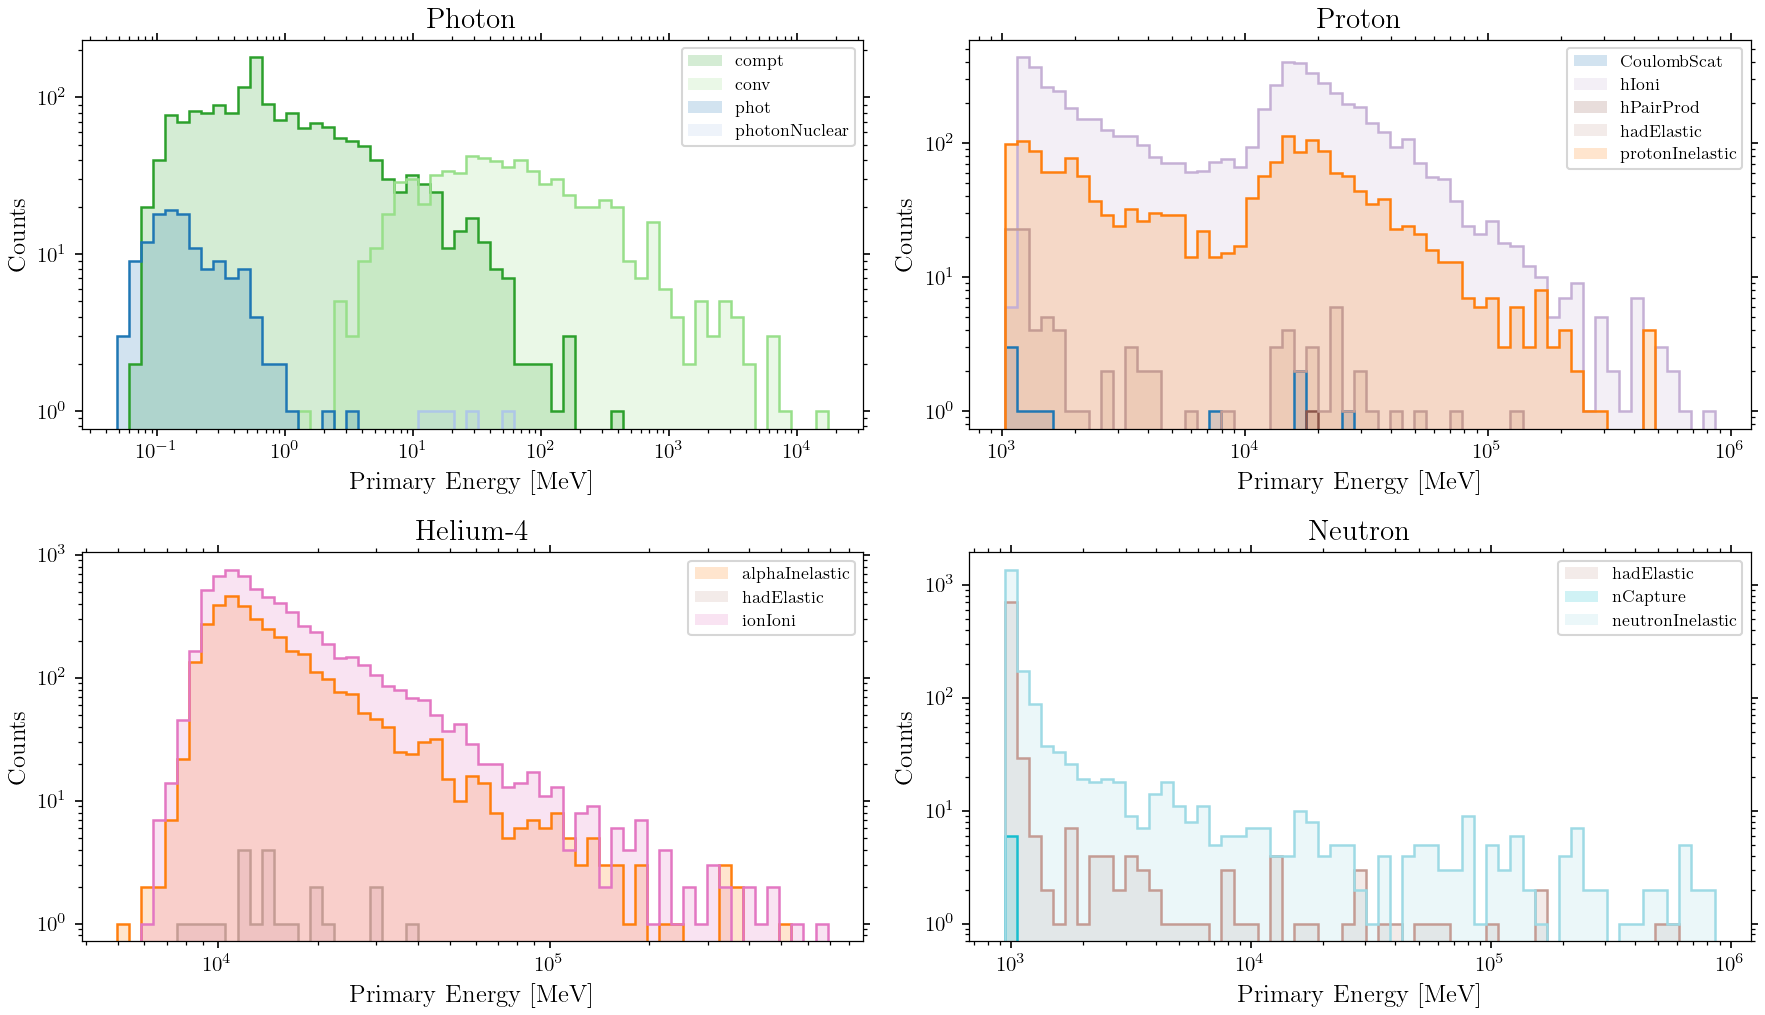

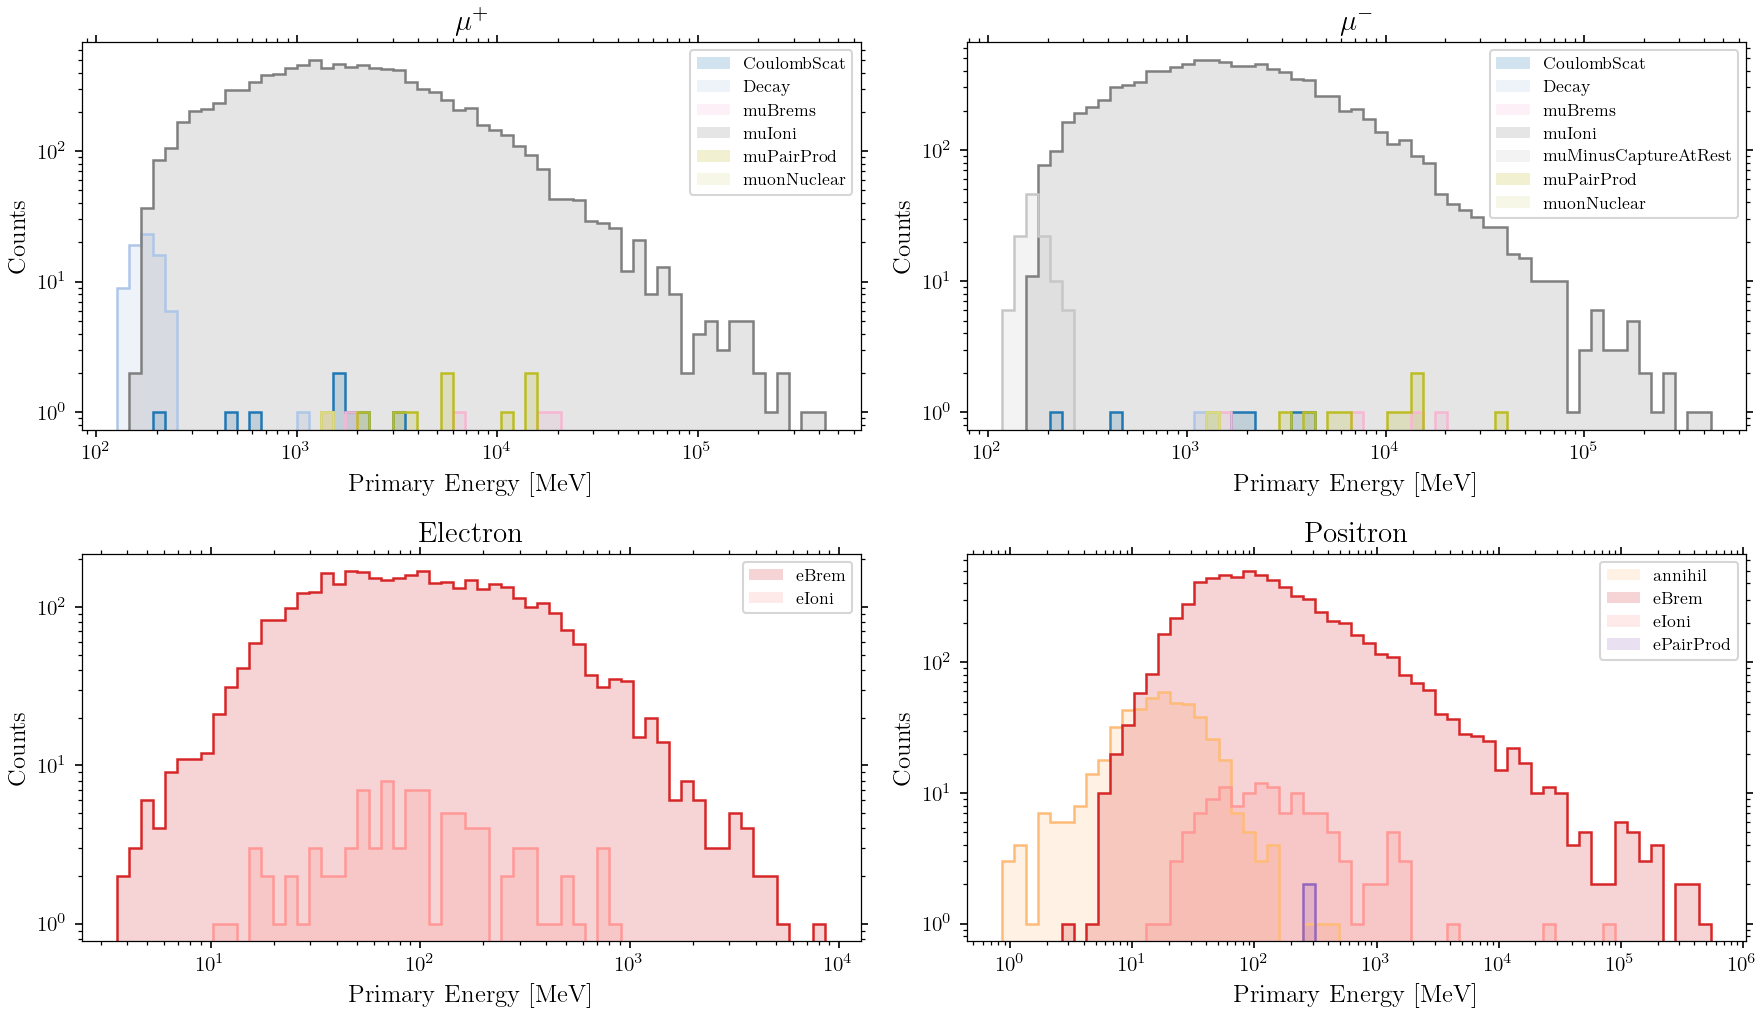

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Groups
group1 = ['photon', 'proton', 'he---4', 'neutro']
group2 = ['muplus', 'mumins', 'electr', 'positr']

particle_names = {
    'neutro': 'Neutron', 'proton': 'Proton', 'he---4': 'Helium-4',
    'muplus': r'$\mu^+$', 'mumins': r'$\mu^-$', 'electr': 'Electron',
    'positr': 'Positron', 'photon': 'Photon'
}

# --- 1. Build Global Color Map ---
# We use tab20 because it offers more distinct colors than tab10
all_labels = set()
for p_data in processed_data.values():
    all_labels.update(p_data.keys())

# Sort labels so the color assignment is deterministic
sorted_labels = sorted(list(all_labels))
color_cycle = plt.cm.tab20.colors 

# Map each label to a specific color
label_to_color = {
    label: color_cycle[i % len(color_cycle)] 
    for i, label in enumerate(sorted_labels)
}

# --- 2. Plotting Function ---
def make_grid_plot(particle_list, data_source, title):
    """
    Creates a 2x2 grid from pre-processed data with consistent coloring.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    for ax, p in zip(axes, particle_list):
        data_dict = data_source.get(p, {})
        
        # Handle empty/missing data
        if not data_dict:
            ax.text(0.5, 0.5, "No Data", ha='center', transform=ax.transAxes)
            ax.set_title(particle_names.get(p, p))
            continue

        labels = sorted(data_dict.keys())
        
        # Prepare arrays for plotting
        plot_data = []
        all_energies = []
        
        for l in labels:
            arr = np.asarray(data_dict[l], dtype=float)
            # Basic cleaning
            arr = arr[np.isfinite(arr) & (arr > 0.0)]
            plot_data.append(arr)
            if arr.size > 0:
                all_energies.append(arr)

        if not all_energies:
            ax.text(0.5, 0.5, "No Events", ha='center', transform=ax.transAxes)
            ax.set_title(particle_names.get(p, p))
            continue

        # Dynamic Binning based on all data in this subplot
        flat_E = np.concatenate(all_energies)
        emin = max(np.min(flat_E), 1e-2)
        emax = np.max(flat_E)
        bins = np.geomspace(emin, emax, 60)

        # Draw Histograms
        for label, Es in zip(labels, plot_data):
            if Es.size == 0: continue
            
            # LOOK UP COLOR FROM GLOBAL MAP
            this_color = label_to_color.get(label, 'black')
            
            # Filled
            ax.hist(Es, bins=bins, histtype="stepfilled", alpha=0.2,
                    color=this_color, label=label)
            # Outline
            ax.hist(Es, bins=bins, histtype="step", linewidth=1.2,
                    color=this_color)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(particle_names.get(p, p))
        ax.legend(fontsize=8, loc='upper right')
        ax.set_xlabel("Primary Energy [MeV]")
        ax.set_ylabel("Counts")

    # fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

# --- Generate the two figures ---
make_grid_plot(group1, processed_data, "Direct Daughter Processes")
make_grid_plot(group2, processed_data, "Direct Daughter Processes")


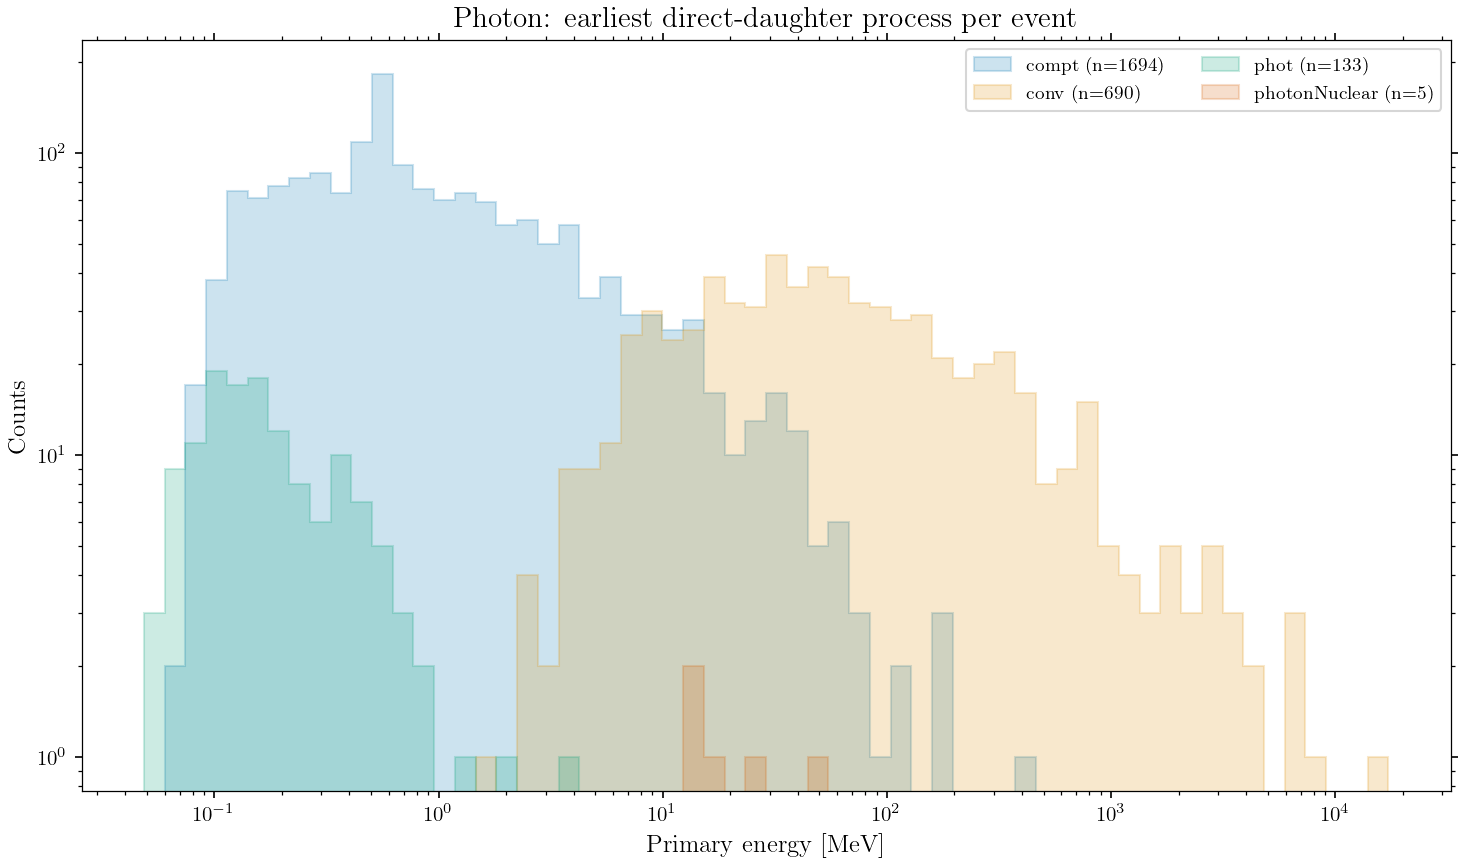

In [10]:
# Photon: per-process primary-energy overlay using Method B.
# One event contributes exactly once, to its earliest direct-daughter process.
photon_data = processed_data.get('photon', {})

labels = sorted(photon_data.keys())

def clean(arr):
    a = np.asarray(arr, dtype=float)
    return a[np.isfinite(a) & (a > 0.0)]

data = [clean(photon_data[l]) for l in labels]
valid = [c for c in data if c.size > 0]
energies = np.concatenate(valid) if valid else np.array([])

emin = max(np.min(energies), 1e-12) if energies.size else 1e-2
emax = np.max(energies) if energies.size else 1.0
bins = np.geomspace(emin, emax, 61)

plt.figure(figsize=(10, 6))
for i, (label, Es) in enumerate(zip(labels, data)):
    if Es.size == 0:
        continue
    plt.hist(
        Es, bins=bins, histtype="stepfilled", alpha=0.2,
        color=colors[i % len(colors)], edgecolor=colors[i % len(colors)],
        linewidth=1.0, label=f"{label} (n={len(Es)})",
    )
plt.loglog()
plt.xlabel("Primary energy [MeV]")
plt.ylabel("Counts")
plt.title("Photon: earliest direct-daughter process per event")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


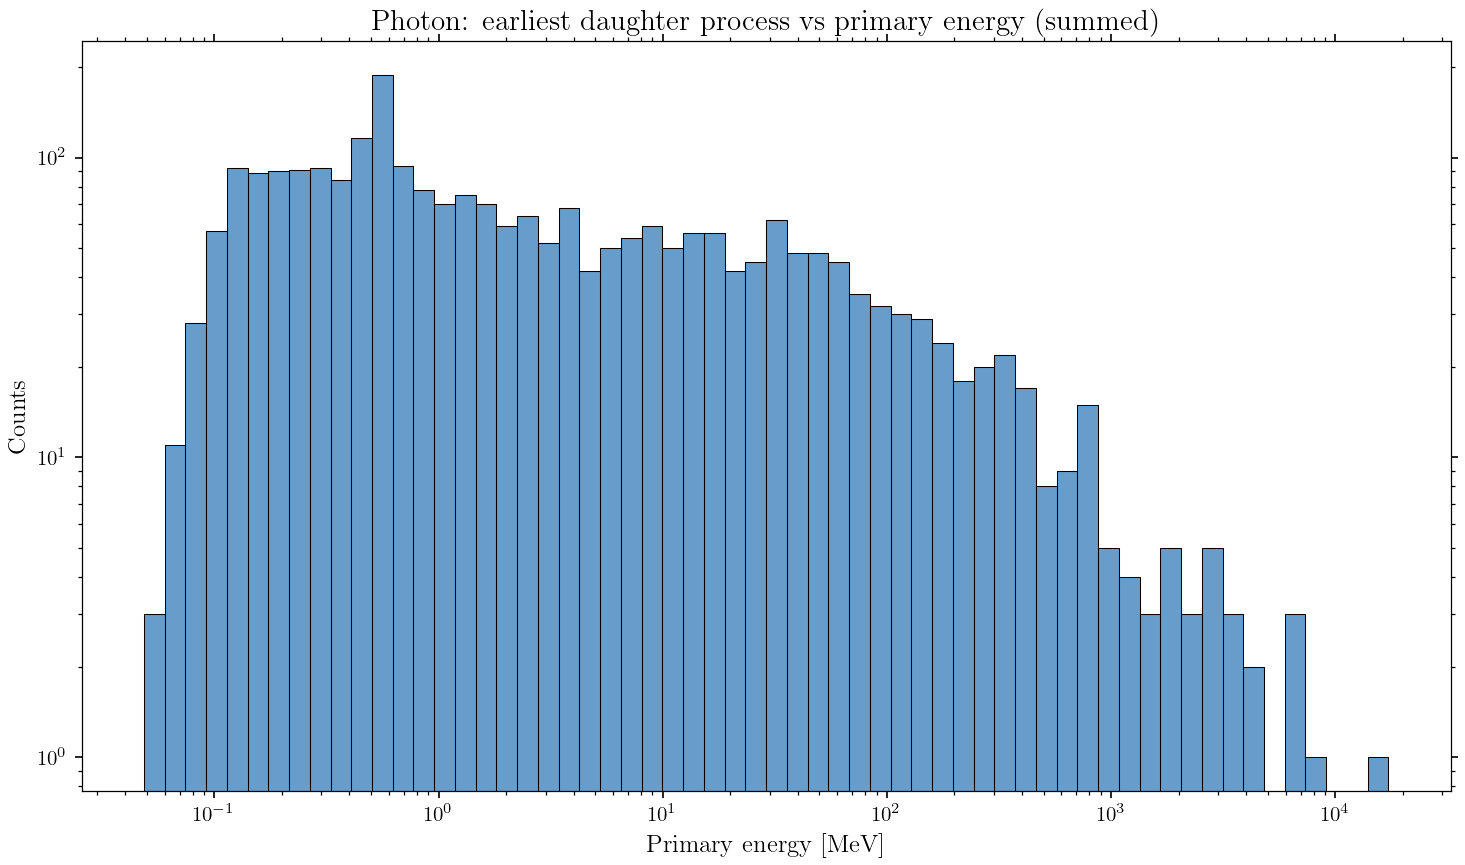

In [8]:
# Summed histogram across all daughter processes (photon).
plt.figure(figsize=(10, 6))
plt.hist(energies, bins=bins, color="#377EB8C1", edgecolor='black', lw=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Primary energy [MeV]")
plt.ylabel("Counts")
plt.title("Photon: earliest daughter process vs primary energy (summed)")
plt.tight_layout()
plt.show()


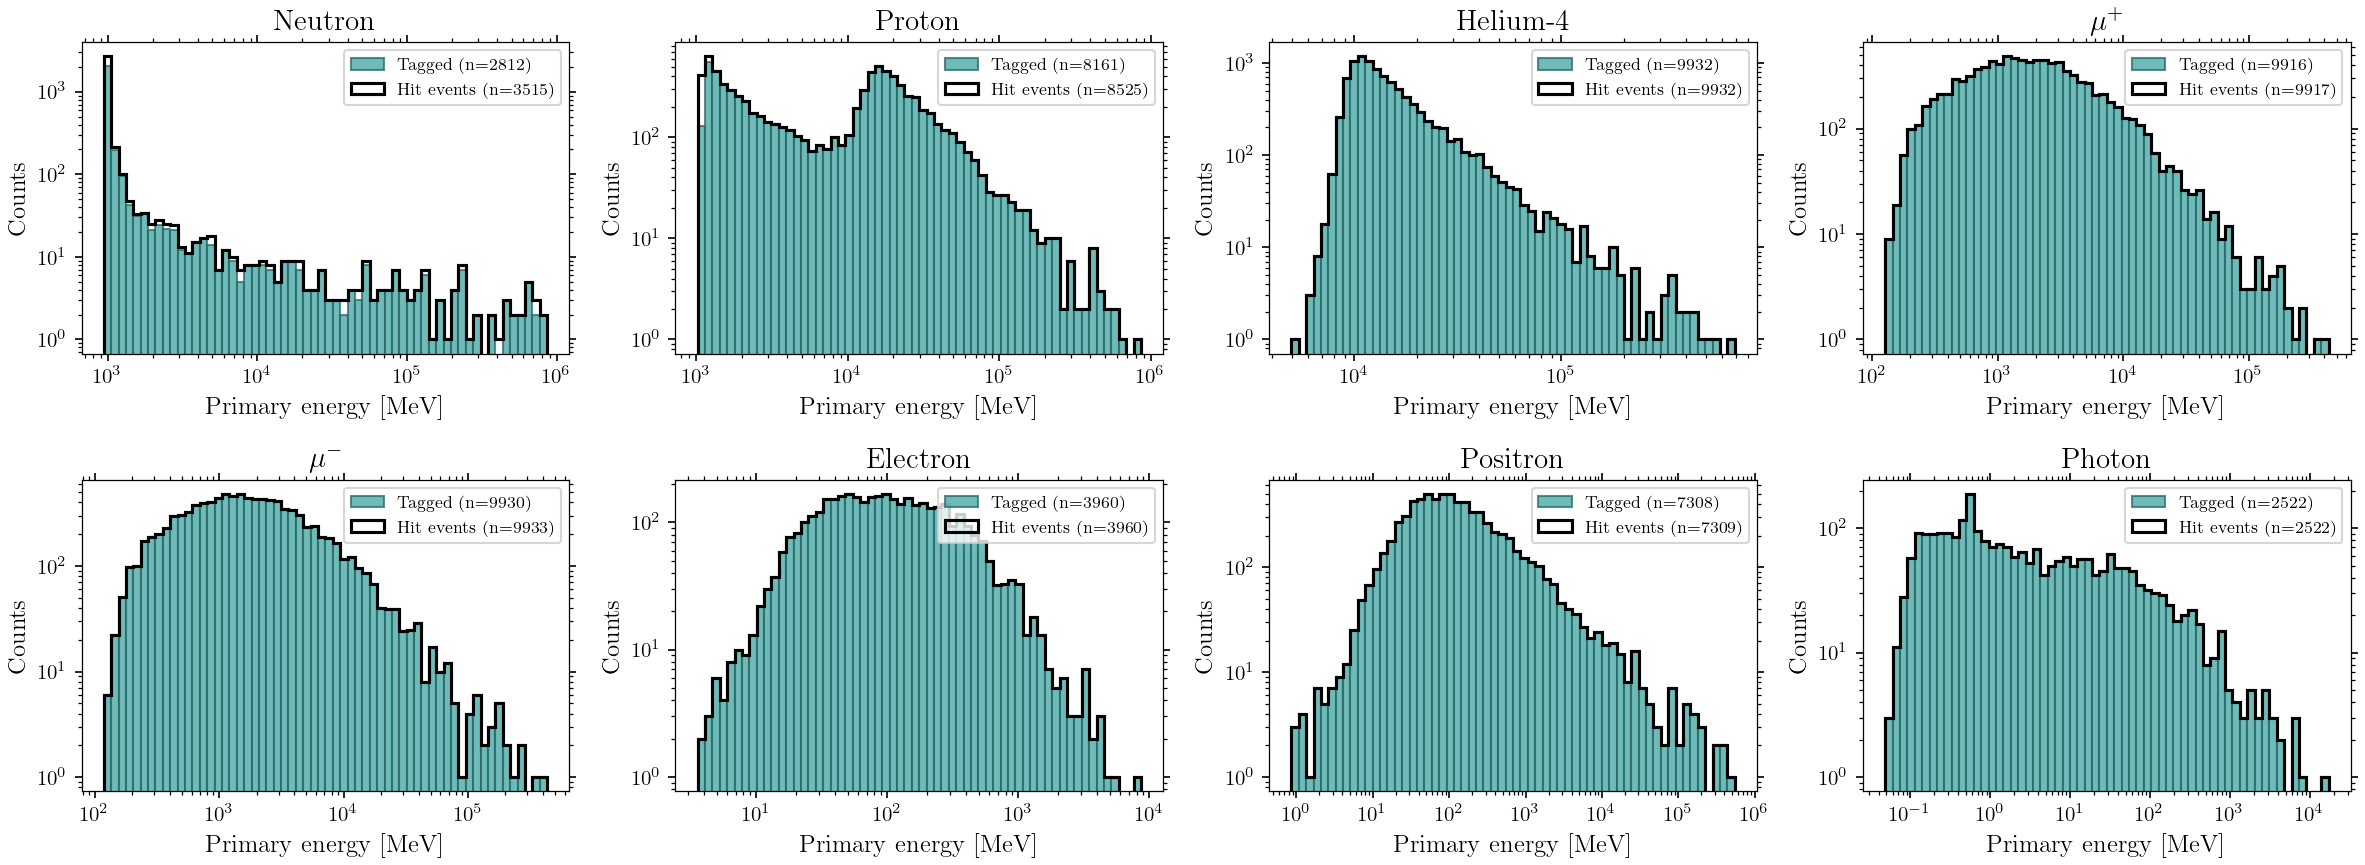

In [9]:
# All-particle comparison: tagged interactions (Method B) vs all hit-producing
# events. Gap between the two = events with hits but no resolvable direct-
# daughter ancestor (hits from primary itself, broken ancestry, etc.).
particle_names = {
    'neutro': 'Neutron', 'proton': 'Proton', 'he---4': 'Helium-4',
    'muplus': r'$\mu^+$', 'mumins': r'$\mu^-$', 'electr': 'Electron',
    'positr': 'Positron', 'photon': 'Photon',
}

particles_in_order = list(PARTICLE_DICT.keys())
ncols = 4
nrows = int(np.ceil(len(particles_in_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

for ax, p in zip(axes.flatten(), particles_in_order):
    # Tagged energies: sum across processed_data for this particle.
    arrs = [np.asarray(v, dtype=float) for v in processed_data.get(p, {}).values()]
    tagged_E = np.concatenate(arrs) if arrs else np.array([])
    tagged_E = tagged_E[np.isfinite(tagged_E) & (tagged_E > 0)]

    hit_E = events_df.loc[
        (events_df['particle'] == p) & (events_df['n_lar_hits'] > 0),
        'primary_energy'
    ].to_numpy()
    hit_E = hit_E[np.isfinite(hit_E) & (hit_E > 0)]

    if hit_E.size == 0 and tagged_E.size == 0:
        ax.text(0.5, 0.5, "No Data", ha='center', transform=ax.transAxes)
        ax.set_title(particle_names.get(p, p))
        continue

    ref = hit_E if hit_E.size else tagged_E
    emin = max(ref.min(), 1e-2)
    emax = ref.max()
    p_bins = np.geomspace(emin, emax, 61)

    if tagged_E.size:
        ax.hist(tagged_E, bins=p_bins, color="#41A6A4C1",
                edgecolor="#2A6866C1", lw=1,
                label=f"Tagged (n={tagged_E.size})")
    if hit_E.size:
        ax.hist(hit_E, bins=p_bins, histtype='step',
                edgecolor='black', lw=1.5,
                label=f"Hit events (n={hit_E.size})")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(particle_names.get(p, p))
    ax.set_xlabel("Primary energy [MeV]")
    ax.set_ylabel("Counts")
    ax.legend(fontsize=8)

# Hide any unused axes
for ax in axes.flatten()[len(particles_in_order):]:
    ax.axis('off')

fig.tight_layout()
plt.show()
